# 04 — Statistical Process Control (SPC)

**Business question:** Is the ER wait-time process in statistical control, or is it drifting? Are
recent unusual days genuine special-cause events, or ordinary noise?


## Methodology

Two independent control charts, both pre-computed in `agg_daily_ops` by dbt (never recomputed here, so
this notebook and the dashboard cannot disagree):

- **XmR chart** on daily median wait. Centre line = mean of daily median wait over the full window;
  control limits = centre ± `spc_sigma` x (mean moving range / 1.128), where 1.128 is the d2 constant
  for a moving range of n=2.
- **p-chart** on daily admission rate. Centre line = pooled admission rate over the full window;
  control limits vary by day because they depend on that day's visit volume:
  centre ± `spc_sigma` x sqrt(p(1-p)/n_day).

A day "signals" under the Western Electric rules implemented in `agg_daily_ops`: a single point beyond
the control limits, a run of 8 consecutive points on one side of the centre line, or 2 of 3 consecutive
points beyond 2 sigma. Full detail in `docs/measure_spec.md`.


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### XmR chart -- daily median wait


In [2]:
wait_chart = metrics.spc_wait_chart(con)
cl, ucl, lcl = wait_chart["wait_centre_line"].iloc[0], wait_chart["wait_ucl"].iloc[0], wait_chart["wait_lcl"].iloc[0]
print(f"Centre line: {cl:.2f} min   UCL: {ucl:.2f} min   LCL: {lcl:.2f} min")
print(f"Signal days: {wait_chart['spc_signal'].notna().sum()} of {len(wait_chart)}")


Centre line: 35.19 min   UCL: 53.98 min   LCL: 16.41 min
Signal days: 3 of 579


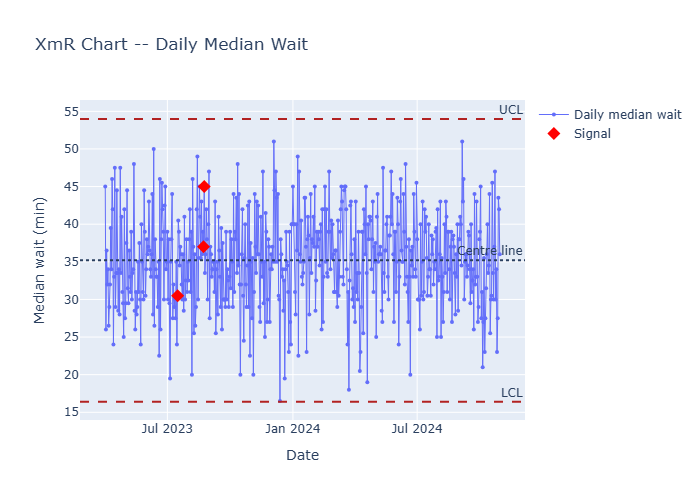

In [3]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=wait_chart["visit_date"], y=wait_chart["median_wait_minutes"],
                          mode="lines+markers", name="Daily median wait",
                          marker={"size": 4}, line={"width": 1}))
sig = wait_chart[wait_chart["spc_signal"].notna()]
fig.add_trace(go.Scatter(x=sig["visit_date"], y=sig["median_wait_minutes"], mode="markers",
                          name="Signal", marker={"color": "red", "size": 10, "symbol": "diamond"}))
fig.add_hline(y=cl, line_dash="dot", annotation_text="Centre line")
fig.add_hline(y=ucl, line_dash="dash", line_color="firebrick", annotation_text="UCL")
fig.add_hline(y=lcl, line_dash="dash", line_color="firebrick", annotation_text="LCL")
fig.update_layout(title="XmR Chart -- Daily Median Wait", xaxis_title="Date", yaxis_title="Median wait (min)")
fig.show()


### Signal days (both charts)


In [4]:
signals = metrics.spc_signal_days(con)
signals


,visit_date,median_wait_minutes,wait_ucl,wait_lcl,spc_signal,admission_rate,admit_ucl,admit_lcl,admit_signal
0,2023-07-16,30.5,53.980708,16.406166,run_of_8,0.214286,0.901326,0.099542,NaN
1,2023-08-23,37.0,53.980708,16.406166,run_of_8,0.444444,0.853987,0.146881,NaN
2,2023-08-24,45.0,53.980708,16.406166,run_of_8,0.384615,0.916459,0.084409,NaN
3,2024-08-01,32.5,53.980708,16.406166,NaN,0.178571,0.783907,0.216961,point_beyond_limit


Only 3 of 579 days (0.5%) signal on the wait chart, all `run_of_8` (a sustained run on one side of the
centre line, not a single extreme point), and they fall in a narrow mid-2023 window. There is no signal
in the second half of the observation window and no trend -- the process looks stable, not drifting.

> **Business decision this supports:** the mid-2023 run is a specific, dateable historical event worth a
> qualitative look-back (what happened operationally in that window), not a recurring pattern requiring
> an ongoing intervention.


### p-chart -- daily admission rate


In [5]:
admit_chart = metrics.spc_admit_chart(con)
admit_cl = admit_chart["admit_centre_line"].iloc[0]
print(f"Pooled centre line (admission rate): {admit_cl:.3f}")
print(f"Signal days: {admit_chart['admit_signal'].notna().sum()} of {len(admit_chart)}")
print(f"Days with clipped limits (low-volume, limits touch 0 or 1): {admit_chart['admit_limits_clipped'].sum()}")


Pooled centre line (admission rate): 0.500
Signal days: 1 of 579
Days with clipped limits (low-volume, limits touch 0 or 1): 19


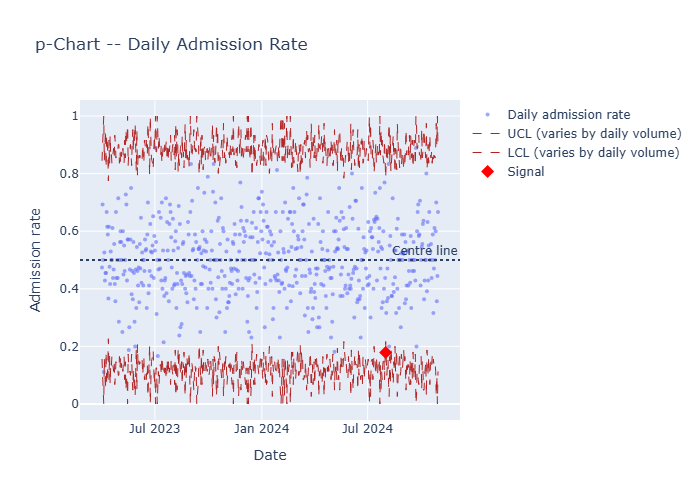

In [6]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=admit_chart["visit_date"], y=admit_chart["admission_rate"], mode="markers",
                          name="Daily admission rate", marker={"size": 4, "opacity": 0.6}))
fig.add_trace(go.Scatter(x=admit_chart["visit_date"], y=admit_chart["admit_ucl"], mode="lines",
                          name="UCL (varies by daily volume)", line={"color": "firebrick", "dash": "dash", "width": 1}))
fig.add_trace(go.Scatter(x=admit_chart["visit_date"], y=admit_chart["admit_lcl"], mode="lines",
                          name="LCL (varies by daily volume)", line={"color": "firebrick", "dash": "dash", "width": 1}))
fig.add_hline(y=admit_cl, line_dash="dot", annotation_text="Centre line")
sig2 = admit_chart[admit_chart["admit_signal"].notna()]
fig.add_trace(go.Scatter(x=sig2["visit_date"], y=sig2["admission_rate"], mode="markers",
                          name="Signal", marker={"color": "red", "size": 10, "symbol": "diamond"}))
fig.update_layout(title="p-Chart -- Daily Admission Rate", xaxis_title="Date", yaxis_title="Admission rate")
fig.show()


Exactly 1 of 579 days signals on the admission-rate chart (`point_beyond_limit`, 2024-08-01) -- a single
isolated day, with no surrounding pattern. Control limits widen visibly on lower-volume days, as
expected for a proportion chart; a handful of days have limits that clip at 0 or 1 and are flagged as
uninformative in the underlying mart rather than silently drawn as if meaningful.

> **Business decision this supports:** neither chart shows a sustained shift in the underlying process --
> there is no evidence of ongoing degradation in either wait time or admission rate that would justify an
> urgent operational escalation right now.


## Executive Summary

Both control charts show a highly stable process: only 3 of 579 days (0.5%) signal on the wait-time
chart and 1 of 579 (0.2%) on the admission-rate chart, with no trend and no repeated clustering outside
one narrow mid-2023 window. Critically, "in control" is not the same as "meeting target" -- notebook 02
already showed that only 40.7% of visits meet the 30-minute wait target, and that gap persists
consistently day after day rather than appearing as an SPC anomaly.

## Business Recommendations

- Do not treat the mid-2023 run-of-8 window as an ongoing issue -- it is a bounded historical event
  worth a qualitative retrospective, not a live escalation.
- Because the process is *stable but below target*, the fix is structural (see notebooks 02 and 03:
  process/throughput changes), not an SPC-triggered corrective action -- chasing day-to-day fluctuation
  here would be reacting to noise.
- Continue running this chart on a rolling basis once new data lands, since its value is in catching a
  *future* genuine shift, not in this one-time historical read.

## Limitations

- **Baseline sensitivity:** the centre line and limits are computed over the entire observation window
  as the baseline (`docs/limitations.md`). If that baseline itself contains a real shift, the limits
  absorb it and the chart understates instability. No separate baseline period is configured in this
  project.
- SPC signals flag statistical unusualness, not clinical or operational cause -- the 2023-07/08 run and
  the 2024-08-01 admission spike would need a manual operational look-back to explain, which this
  dataset (no free-text notes, no staffing log) cannot support.

## Next Steps

`05_satisfaction.ipynb` turns to a different quality dimension -- patient-reported satisfaction -- and
whether its very low response rate biases what gets reported.
